# Standalone ConVAE Example

This notebook demonstrates a standalone implementation of a Conditional Variational Autoencoder (conVAE class).

## Notebook Structure
1. **Environment & Imports** – Load required libraries.
2. **Causal Dataset Simulation** – Simulate a toy dataset as the original dataset.
3. **Data Preprocessing** – Standardize continuous variables and extract the categorical vocabulary used for label encoding.
4. **Model Training** – Learn the generating mechanisms of T, X | T, and (Y(0),Y(1)) | X, T.
5. **Data Generation** – Generate synthetic data by sequentially sampling T', then X' | T', and finally (Y'(0),Y'(1)) | X, T.
6. **Evaluation & Visualization** – Evaluate distributional and causal fidelity between synthetic data and original data.

### **Environment & Imports** – Load required libraries.

In [0]:
# check GPU availability
import torch
import os

print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")
print("numer of cores:",os.cpu_count())


CUDA available: True
GPU name: NVIDIA L40S
numer of cores: 8


In [0]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [0]:
from causalmix import (
    CausalMix,
    conVAE,
    SynthEval,
    CausalEval,
    DataSchema,
    VarIndex,
    fit_metadata,
    preprocess_with_meta,
    postprocess_generated,
    build_table_distributional_fidelity,
    build_table_privacy,
    build_table_causal_structure,
    eval_tables_mean,
    single_column_plot,
    pair_column_plot,
    plot_joint_embedding_2d,
)


### Data Generating Process (DGP)

We simulate a binary treatment and binary outcome setting with mixed-type covariates.

For each unit i = 1, …, n:

#### Covariates

X_i = (X_bin, X_cat, X_exp, X_uniform, X_beta)

- X_bin ~ Bernoulli(0.4)
- X_cat ∈ {A, B, C}
- X_exp ~ Exponential(1)
- X_uniform ~ Uniform(-3, 3)
- X_beta ~ Beta(2, 5)

Categorical variables are one-hot encoded to form the design vector X_design.

#### Treatment

T_i ~ Bernoulli(0.5)

(Treatment is randomized; overlap can be modified by changing the assignment mechanism.)

#### Potential Outcomes

logit P(Y_i(0) = 1 | X_i) = X_design · β  
logit P(Y_i(1) = 1 | X_i) = X_design · β + τ

where β is a fixed coefficient vector and τ = 0.5 is the treatment effect on the log-odds scale.

The observed outcome is:

Y_i = T_i * Y_i(1) + (1 − T_i) * Y_i(0)

This setup provides a simple but heterogeneous tabular dataset suitable for illustrating conVAE.

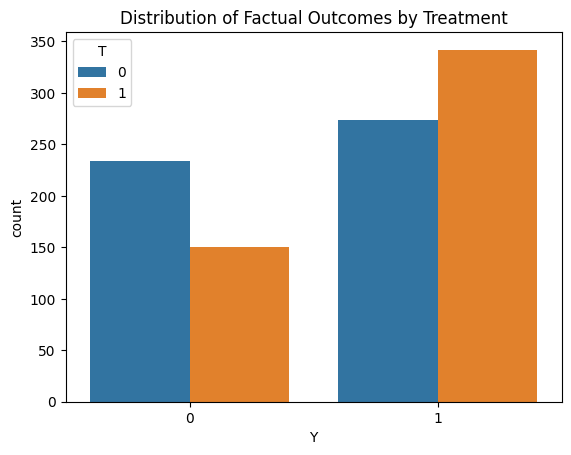

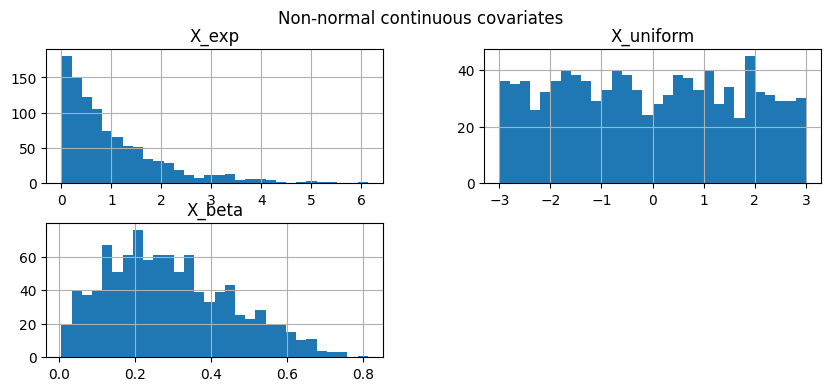

In [0]:
# simulate a toy causal dataset
np.random.seed(42)

n = 1000

# -----------------------------
# Covariates
# -----------------------------
# Binary variable
X_bin = np.random.binomial(1, 0.4, size=n) 

# Categorical variable (3 levels)
X_cat = np.random.choice(['A', 'B', 'C'], size=n, p=[0.3, 0.5, 0.2])

# Continuous non-normal variables
X_exp = np.random.exponential(scale=1.0, size=n)         # skewed right
X_uniform = np.random.uniform(-3, 3, size=n)             # flat distribution
X_beta = np.random.beta(a=2, b=5, size=n)                # bounded, skewed

# Stack into design matrix for potential outcome model
# For the categorical variable, we’ll one-hot encode when computing logits
X_cat_dummies = pd.get_dummies(X_cat, drop_first=True)  # B, C vs baseline A
X_design = np.column_stack([X_bin, X_exp, X_uniform, X_beta, X_cat_dummies.values])

# Build full covariate dataframe
X = pd.DataFrame({
    'X_bin': X_bin,
    'X_cat': X_cat,
    'X_exp': X_exp,
    'X_uniform': X_uniform,
    'X_beta': X_beta
})

# -----------------------------
# Treatment assignment
# -----------------------------
T = np.random.binomial(1, 0.5, size=n) # overlap can be controlled by modifying the treatment 

# -----------------------------
# Potential outcomes
# -----------------------------
# Coefficients: binary + 3 continuous + 2 dummies = 6 vars
coef = np.array([0.5, -0.3, 0.2, 0.4, 0.6, -0.2])

logit_Y0 = np.dot(X_design, coef)
prob_Y0 = 1 / (1 + np.exp(-logit_Y0))

logit_Y1 = logit_Y0 + 0.5  # treatment effect can vary dependening on covariates by modifying here
prob_Y1 = 1 / (1 + np.exp(-logit_Y1))

Y0 = np.random.binomial(1, prob_Y0)
Y1 = np.random.binomial(1, prob_Y1)
Y = Y1 * T + Y0 * (1 - T)

# -----------------------------
# Build dataframe
# -----------------------------
df = pd.DataFrame({
    'X_bin': X_bin,
    'X_cat': X_cat,
    'X_exp': X_exp,
    'X_uniform': X_uniform,
    'X_beta': X_beta,
    'T': T,
    'Y': Y
})

# -----------------------------
# Visualization
# -----------------------------
sns.countplot(x='Y', hue='T', data=df)
plt.title("Distribution of Factual Outcomes by Treatment")
plt.show()

# Quick look at distributions
df[['X_exp', 'X_uniform', 'X_beta']].hist(bins=30, figsize=(10, 4))
plt.suptitle("Non-normal continuous covariates")
plt.show()


### **Data Preprocessing** – Standardize continuous variables and extract the categorical vocabulary used for label encoding.

In [0]:
# data preprocessing
df_meta = fit_metadata(df = df, numerical_var = ['X_exp', 'X_uniform', 'X_beta'], binary_var = ['X_bin', "T", "Y"], categorical_var = ['X_cat'])
df_preprocessed = preprocess_with_meta(df = df, meta = df_meta)

In [0]:
X.columns.tolist()

['X_bin', 'X_cat', 'X_exp', 'X_uniform', 'X_beta']

In [0]:
df_preprocessed.columns.to_list()

['X_bin', 'T', 'Y', 'X_cat', 'X_exp', 'X_uniform', 'X_beta']

### **Model Training** – Learn the generating mechanisms of T, X | T, and (Y(0),Y(1)) | X, T.

In [0]:
# Learn the generating mechanism of X | T
# specify an overlap function
def overlap_fn(X, index):
    return 0 
# we can also specify a function with less overlap, such as
# def overlap_fn(X, index):
#     X_bin = index.slice(X, "X_bin")
#     return 5 * X_bin

model_X = conVAE(
    df_preprocessed,
    Ynames = X.columns.tolist(),  # random variable to be generated / inputted
    Xnames=["T"],  # random variable to condition on
    binary_cols=["X_bin", "T"],  # binary columns
    categorical_cols=["X_cat"],      # list of categorical columns in Ynames
    categorical_dims={"X_cat": 3},      # dict {col_name: num_classes}
    var_bounds={},  # variable lower and upper bounds
    latent_dim=5,  # latent space dimensions
    hidden_dim=[64],  # perceptrons in each layer
    overlap_weight = 1e1,
    overlap_target = overlap_fn,
)
model_X.fit_model()

INFO:pytorch_lightning.utilities.rank_zero:Using bfloat16 Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/pytorch_lightning/utilities/model_summary/model_summary.py:242: UserWarning:

Precision bf16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.



┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder      │ Sequential │    384 │ train │     0 │
│ 1 │ en_mu        │ Linear     │    325 │ train │     0 │
│ 2 │ en_logvar    │ Linear     │    325 │ train │     0 │
│ 3 │ decoder      │ Sequential │    448 │ train │     0 │
│ 4 │ output_heads │ ModuleDict │    455 │ train │     0 │
│ 5 │ var_heads    │ ModuleDict │    325 │ train │     0 │
└───┴──────────────┴────────────┴────────┴───────┴───────┘

Trainable params: 2.3 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.3 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 22                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/pytorch_lightning/utilities/_pytree.py:21: FutureWarning:

`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: PossibleUserWarning:

The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: PossibleUserWarning:

The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.



In [0]:
# Last logged validation loss from the final epoch
last_val_X = model_X.trainer.callback_metrics.get("val_loss")
print("Last val_loss for X:", float(last_val_X) if last_val_X is not None else "N/A")

Last val_loss for X: -2.5054688453674316


In [0]:
# fit bayesian gaussian mixture model for X
model_X.fit_bgmm_from_training_latents()

{'bgm': BayesianGaussianMixture(max_iter=1000, n_components=5, n_init=10,
                         random_state=42, reg_covar=1e-05),
 'log_var_mean': array([-4.2636094, -5.3195553, -5.506413 , -6.515524 , -6.8067217],
       dtype=float32)}

In [0]:
# Learn the generating machanism of T
model_T = df_preprocessed["T"].mean()
'''
# alternatively, we can use conVAE to fit T, which may be time comsuming
# model_T = conVAE(
    df=self.data_processed,
    Xnames=[],
    Ynames="T",
    binary_cols=["T"],
    latent_dim=1,
    hidden_dim=16,
) 
model_T.fit_model()
# fit the bgmm for treatment
# model_T.fit_bgmm_from_training_latents()
'''

'\n# alternatively, we can use conVAE to fit T, which may be time comsuming\n# model_T = conVAE(\n    df=self.data_processed,\n    Xnames=[],\n    Ynames="T",\n    binary_cols=["T"],\n    latent_dim=1,\n    hidden_dim=16,\n) \nmodel_T.fit_model()\n# fit the bgmm for treatment\n# model_T.fit_bgmm_from_training_latents()\n'

In [0]:
# Learn the generating machanism of outcome Y(0),Y(1) | X, T
model_po = conVAE(df=df_preprocessed,
           Xnames = X.columns.tolist() + ["T"],
           Ynames = ["Y"],
           binary_cols=["X_bin", "T", "Y"],  
           categorical_cols=['X_cat'],    
           categorical_dims={'X_cat': 3},
           treatment_cols=["T"],
           var_bounds = {},
           latent_dim=2,  # latent space dimensions
           hidden_dim=[64],  # perceptrons in each layer
           batch_size=10,
           potential_outcome=True, # need to specify potential_outcome=True when fitting potential outcomes
           treatment_effect_fn=lambda x, index: 0.1,  # treatment effect function defined by the user
           selection_bias_fn=lambda x, t, index: 0,  # unmeasured confounding bias function defined by the user
           effect_rigidity= 1e3,
           bias_rigidity = 1e3,
           kld_rigidity=0.1)

model_po.fit_model()

INFO:pytorch_lightning.utilities.rank_zero:Using bfloat16 Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/pytorch_lightning/utilities/parsing.py:45: UserWarning:

Attribute 'overlap_target' removed from hparams because it cannot be pickled. You can suppress this warning by setting `self.save_hyperparameters(ignore=['overlap_target'])`.

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-

┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder      │ Sequential │    128 │ train │     0 │
│ 1 │ en_mu        │ Linear     │    130 │ train │     0 │
│ 2 │ en_logvar    │ Linear     │    130 │ train │     0 │
│ 3 │ decoder      │ Sequential │    576 │ train │     0 │
│ 4 │ output_heads │ ModuleDict │    130 │ train │     0 │
│ 5 │ var_heads    │ ModuleDict │    130 │ train │     0 │
└───┴──────────────┴────────────┴────────┴───────┴───────┘

Trainable params: 1.2 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.2 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/pytorch_lightning/utilities/_pytree.py:21: FutureWarning:

`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: PossibleUserWarning:

The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: PossibleUserWarning:

The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.



In [0]:
# Last logged validation loss from the final epoch
last_val_po = model_po.trainer.callback_metrics.get("val_loss")
print("Last val_loss for outcome:", float(last_val_po) if last_val_po is not None else "N/A")

Last val_loss for outcome: 0.23422852158546448


In [0]:
# fit bayesian gaussian mixture model for Y
model_po.fit_bgmm_from_training_latents()

{'bgm': BayesianGaussianMixture(max_iter=1000, n_components=2, n_init=10,
                         random_state=42, reg_covar=1e-05),
 'log_var_mean': array([-1.6127315, -0.700086 ], dtype=float32)}

### **Data Generation** – Generate synthetic data by sequentially sampling T', then X' | T', and finally (Y'(0),Y'(1)) | X, T.

In [0]:
# generate T 
n_samples = 1000
Tgen = torch.bernoulli(torch.full((n_samples, 1), float(model_T)))
T_gen = pd.DataFrame({
    col_name: Tgen[:, i].detach() for i, col_name in enumerate(["T"])
})

In [0]:
# generate X using BGMM
Xgen = model_X.generate_bgmm(x = Tgen)
X_gen = pd.DataFrame({
    col_name: Xgen[:, i].detach() for i, col_name in enumerate(X.columns.tolist())
})

In [0]:
 # generate Y using BGMM
Ygen, Ymean, Ymean_prime, stats = model_po.generate_bgmm(x = torch.cat((Xgen, Tgen), 1))
Y_gen = pd.DataFrame({
    col_name: Ygen[:, i].detach() for i, col_name in enumerate(["Y"])
})

In [0]:
# Description of the generated data
# Ygen: [a realization/sample of the potential outcomes]
# Ymean [the expected value of the potential outcomes, i.e., probabilities or means]
# Ymean_prime [the expected potential outcomes given flipped treatment, i.e., E[Y(0)|X, flipped T] and E[Y(1)|X, flipped T]]
# stats: include the following statistics:
#   - inividual treatment effects
print(stats["ite"][:5])
# - average treatment effect
print("ate:",stats["ate"].detach())
# - individual unmeasured confounding bias: T*(y0 - y0') + (1-T)*(y1' - y1)
print(stats["bias"][:5])
# - average unmeasured confounding bias
print("unmeasured confounding bias:", stats["avg_bias"].detach())

tensor([[0.0849],
        [0.1034],
        [0.0991],
        [0.0849],
        [0.0991]])
tensor([0.1017])
tensor([[1.5398e-03],
        [1.7881e-06],
        [2.3502e-04],
        [7.9459e-04],
        [3.5763e-07]])
tensor([-0.0002])


In [0]:
# postprocessing columns
df_gen = pd.concat([X_gen, T_gen, Y_gen], axis=1)
df_gen = postprocess_generated(df_gen, df_meta)
# show the generated data
df_gen.head()

,X_bin,T,Y,X_cat,X_exp,X_uniform,X_beta
0,1,1,1,B,3.876584,2.748312,0.195676
1,0,0,1,A,3.017485,0.463410,0.641554
2,1,1,1,B,3.342281,3.241824,0.454107
3,1,1,1,B,4.614891,2.534489,0.021849
4,1,0,1,B,4.617269,2.790330,0.279132


### **Evaluation & Visualization** – Evaluate distributional and causal fidelity between synthetic data and original data.

In [0]:
schema = DataSchema(
    numeric = ["X_exp", "X_uniform", "X_beta"],
    binary = ["X_bin", "T", "Y"],
    categorical = ["X_cat"]
)

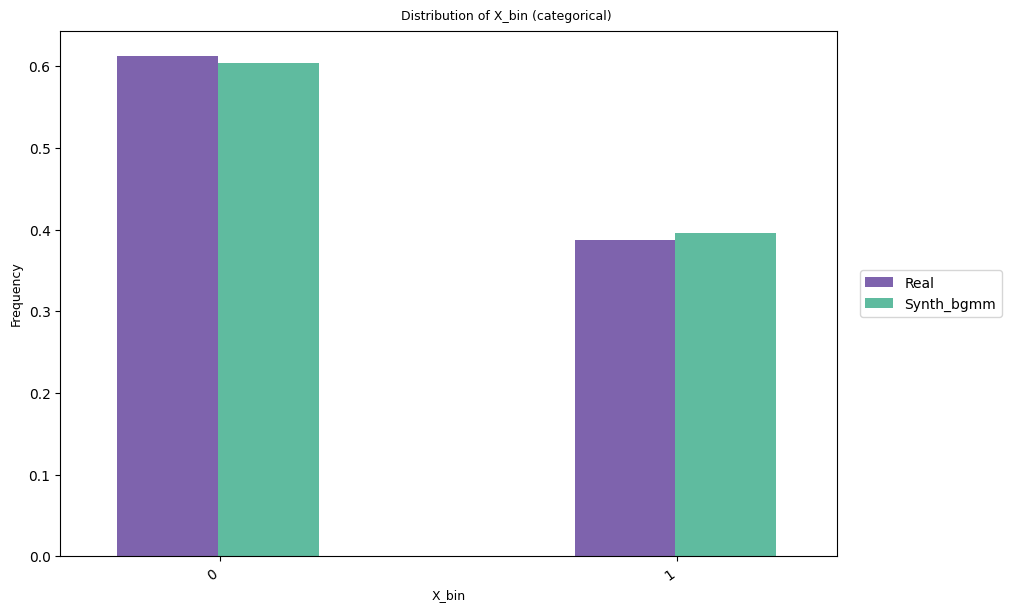

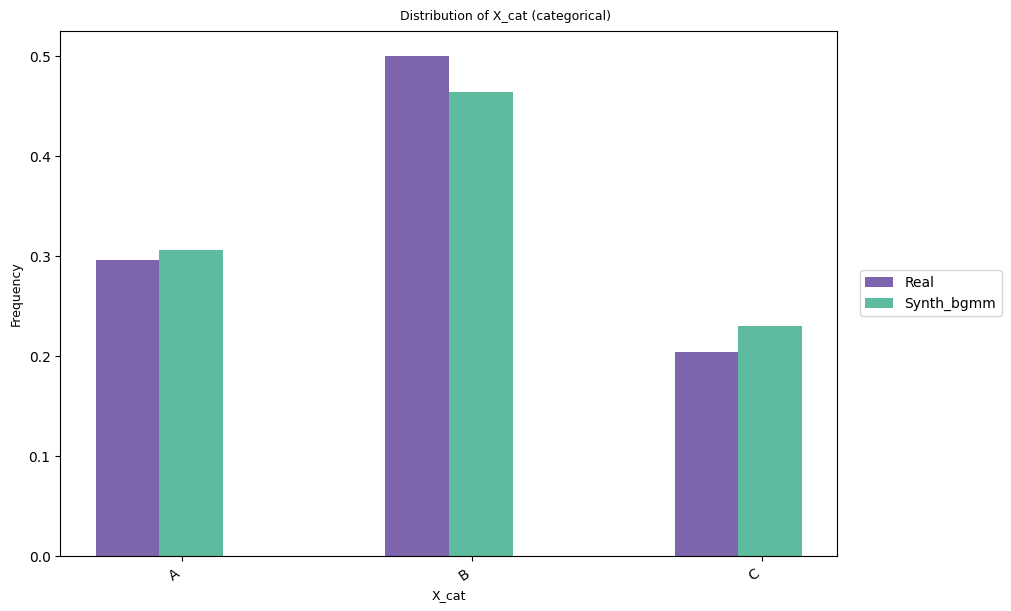

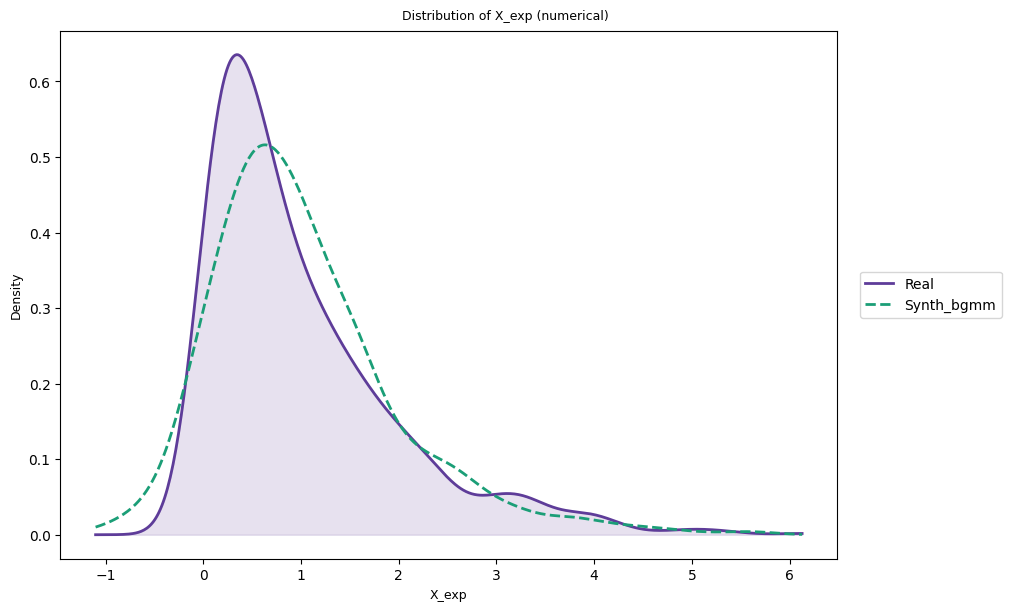

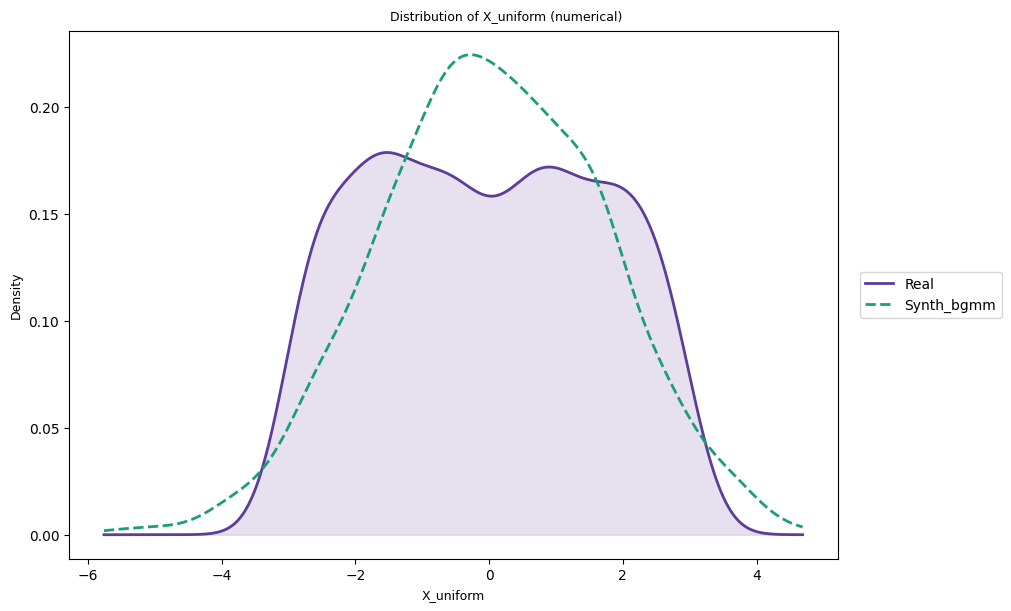

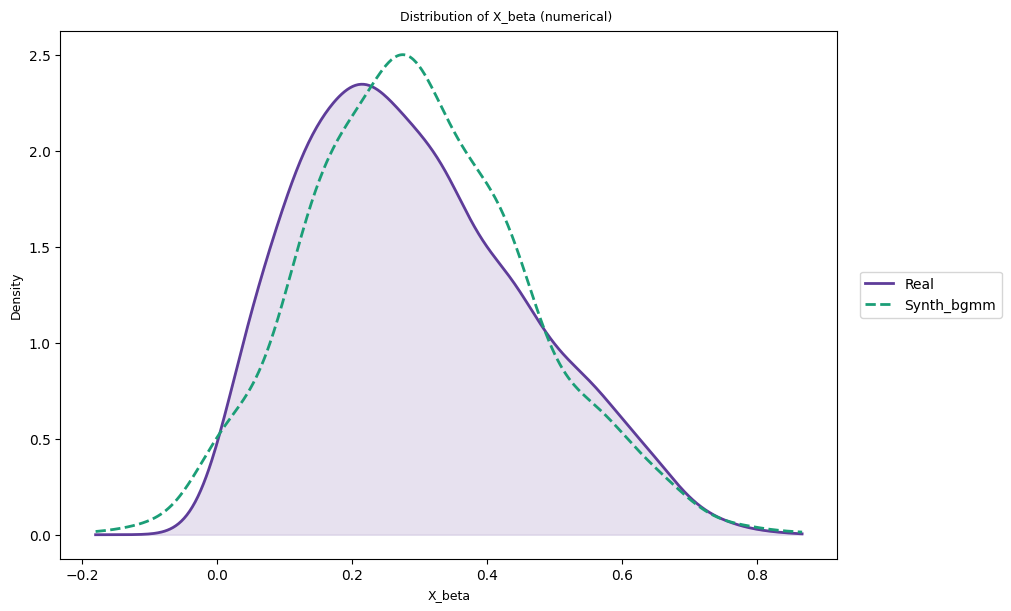

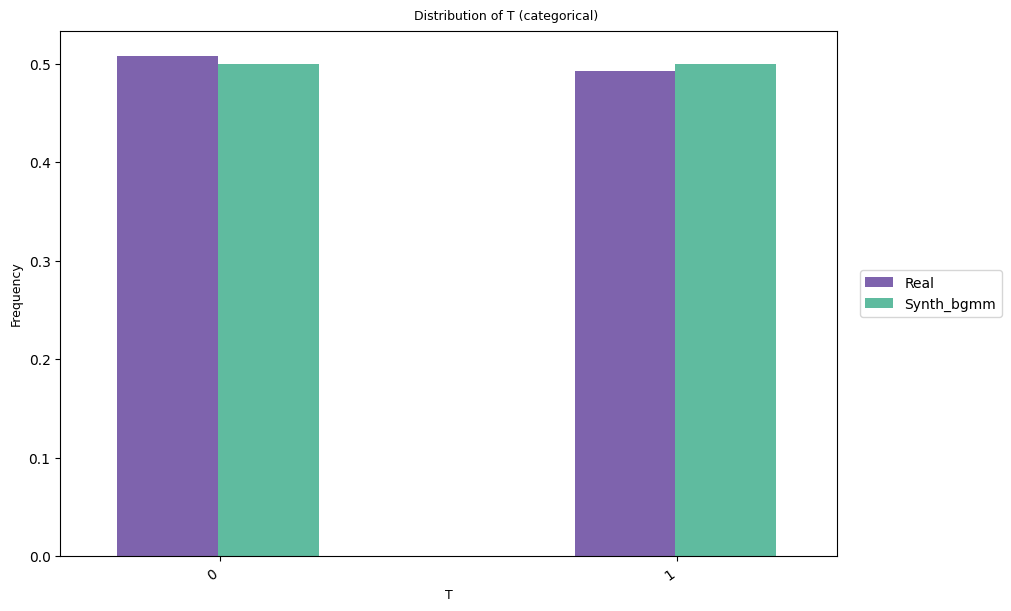

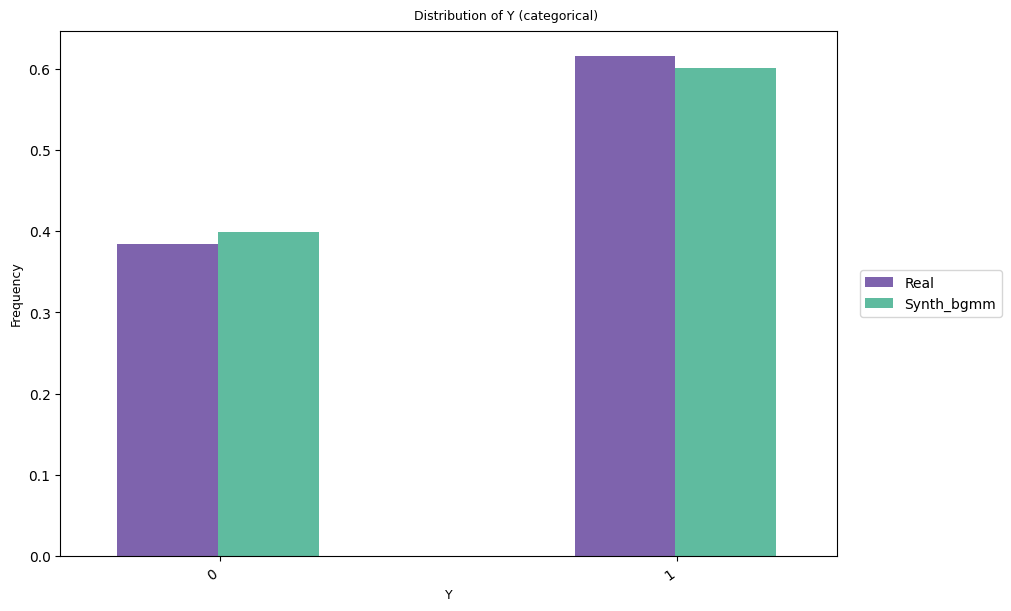

In [0]:
# check marginal distributionss
synth_dict = {
    "Synth_bgmm": df_gen,
}
# single column plots
for var in df.columns:
    fig = single_column_plot(
        real_data=df,
        synthetic_data=synth_dict,
        schema=schema,
        column_name=var,
        #main_title="Marginal distribution of age",
        x_label=var,
        y_label=None,
        fig_size=(10,6),
        legend_outside=True,
        #show_hist = True,
    )
    fig.show()

In [0]:
# overlap metrics
overlap_metrics = model_X.overlap_diagnostics(Xgen, Tgen) 
print("Overlap metrics:", {k: round(v, 4) for k, v in overlap_metrics.items()})

Overlap metrics: {'dec/log_ratio_mean': 0.0, 'dec/log_ratio_std': 0.0, 'dec/target_mean': 0.0, 'dec/target_std': 0.0, 'dec/mse_to_target': 0.0, 'dec/fraction_within_tol': 1.0, 'ps/auc': 0.542, 'ps/hist_overlap_coeff': 0.924, 'ps/frac_common_support': 1.0, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 1.0}


/databricks/python/lib/python3.10/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.



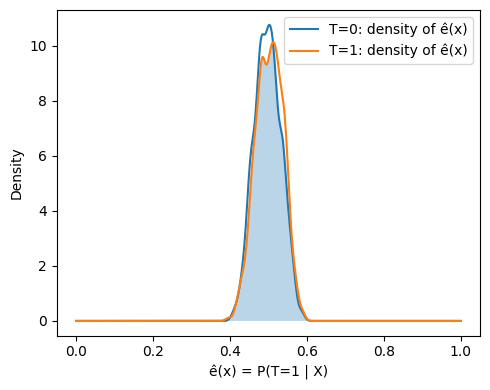

CausalEvalResults(mae_tau=0.004, corr_tau=nan, ate_pred=0.102, ate_target=0.1, ate_abs_error=0.002, tau_wasserstein=0.004, mae_kappa=0.001, mae_kappa_t0=0.0, mae_kappa_t1=0.001, kappa_wasserstein=0.001, overlap_coeff=0.929, bw0=0.031, bw1=0.031)


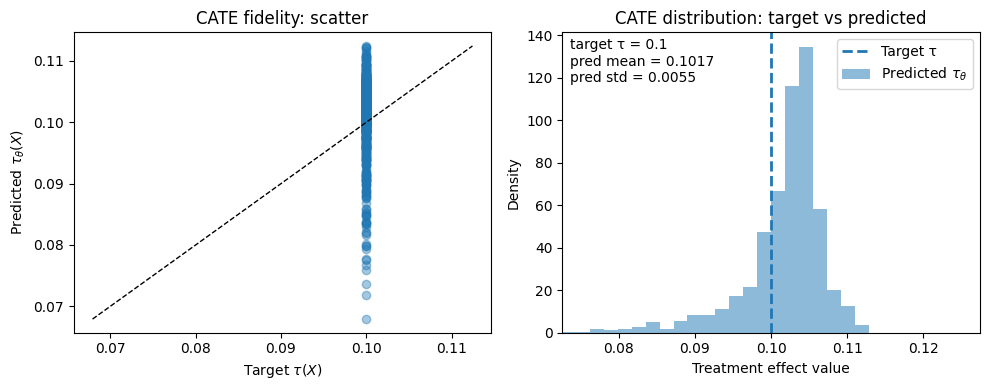

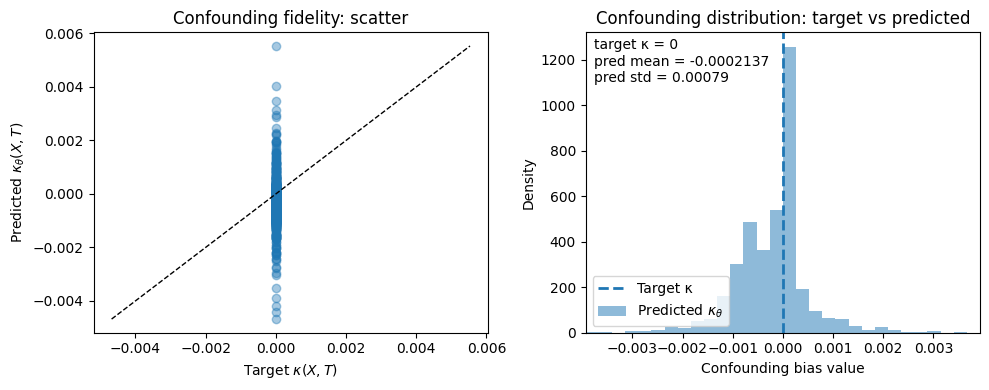

In [0]:
# We can also do a comprehensive evaluation of causal properties including overlap, treatment effect and unmeasured confounding 
X_np = Xgen.detach().cpu().numpy() # shape (N, V)
T_np = Tgen.detach().cpu().numpy().reshape(-1) # shape (N, )

# 3) Predicted τ and κ from m_post stats
tau_pred = stats["ite"].detach().cpu().numpy()      # shape [N, V] or [N]
kappa_pred = stats["bias"].detach().cpu().numpy()   # shape [N, V] or [N]
n_samples = tau_pred.shape[0]
# 4) Target τ(X), κ(X, T) from user’s functions f, g
#    (these are exactly your effect / bias functions passed to conVAE)

tau_pred = np.squeeze(tau_pred) # shape (N, )
kappa_pred = np.squeeze(kappa_pred) # shape (N, )

def _to_numpy(x):
    """Convert torch.Tensor or scalar to numpy array safely."""
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    else:
        return np.asarray(x)

index = VarIndex(X.columns.tolist())
tau_target = _to_numpy(model_po.f(X_gen, index))
kappa_target = _to_numpy(model_po.g(X_gen, T_gen, index)) # shape of Tgen[:,0] is [N]

if tau_target.shape == ():
    tau_target = np.full(n_samples, float(tau_target))
else:
    tau_target = np.squeeze(tau_target)

if kappa_target.shape == ():
    kappa_target = np.full(n_samples, float(kappa_target))
else:
    kappa_target = np.squeeze(kappa_target)

ce = CausalEval(
    tau_pred=tau_pred,
    tau_target=tau_target,
    kappa_pred=kappa_pred,
    kappa_target=kappa_target,
    T=T_np,
    X=X_np
)

# 6) Collect everything
metrics = ce.all_metrics(plot = True)
print(metrics)

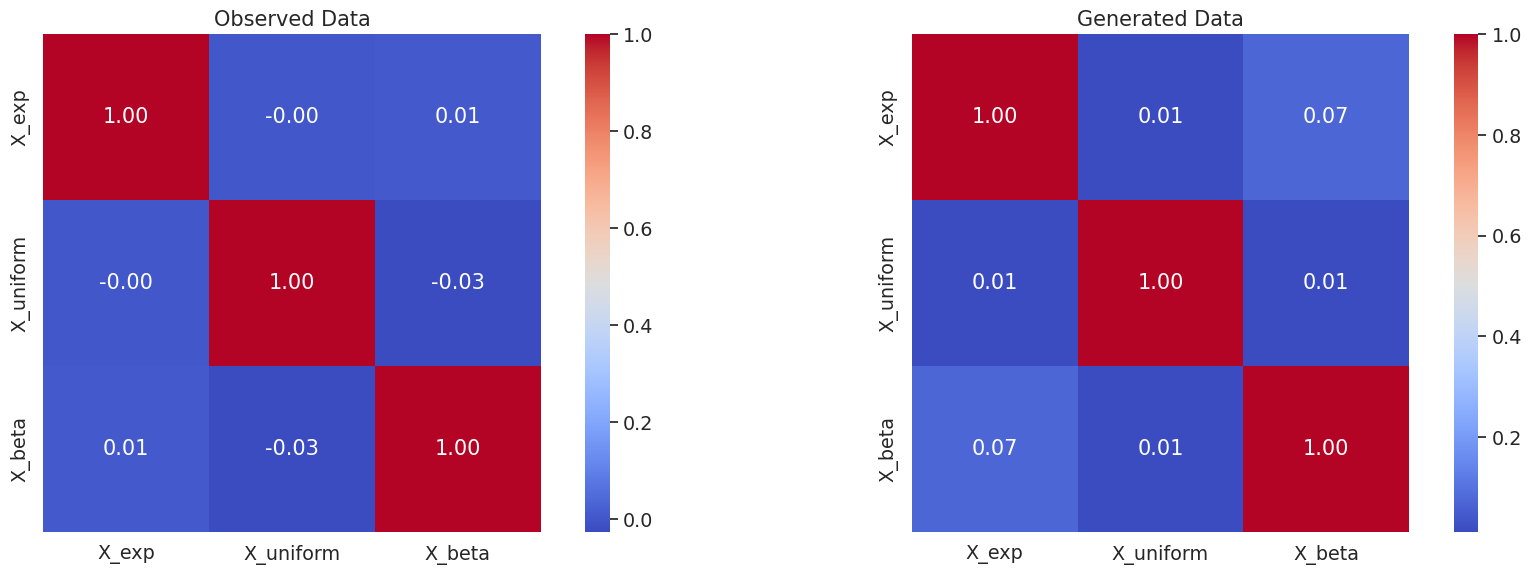

In [0]:
# check correlation between continuous generated X and original X
import seaborn as sns
import matplotlib.pyplot as plt

# Plot side by side
fig, ax = plt.subplots(ncols=2, figsize=(18, 6))

numerical_var = ["X_exp", "X_uniform", "X_beta"]
# Observed data correlation
sns.heatmap(df[numerical_var].corr(), ax=ax[0], square=True, annot=True, 
            fmt=".2f", cmap="coolwarm", annot_kws={"size": 12})
ax[0].set_title("Observed Data", fontsize=14)
ax[0].tick_params(labelsize=12)
ax[0].grid(False)

# Generated data correlation
sns.heatmap(df_gen[numerical_var].corr(), ax=ax[1], square=True, annot=True, 
            fmt=".2f", cmap="coolwarm", annot_kws={"size": 12})
ax[1].set_title("Generated Data", fontsize=14)
ax[1].tick_params(labelsize=12)
ax[1].grid(False)

plt.tight_layout()
plt.show()